# Inferencia del parámetro $g = h/J$ y fase del TFIM a partir de $|\psi_0\rangle$

$$H = -J \sum_i \sigma^z_i \sigma^z_{i+1} - h \sum_i \sigma^x_i$$

**Objetivo:** dado $|\psi_0\rangle$ con ruido de medida, inferir $g = h/J$, $E_0/N$
y la fase (FM / Crítico / PM). En un segundo paso, a partir del $g$ predicho
reconstruimos por diagonalización exacta la $\langle |m| \rangle$ y la
$\chi$ implícitas y las comparamos con las del estado real.

El estado se perturba con ruido gaussiano para simular errores experimentales:
$$|\tilde{\psi}_0\rangle = \frac{|\psi_0\rangle + \eta\,|\xi\rangle}{\||\psi_0\rangle + \eta\,|\xi\rangle\|}, \qquad |\xi\rangle \sim \mathcal{N}(0, I)$$

**Convención $g = h/J$** (con $J = 1$ fijo): el diagrama de fases del TFIM 1D
tiene una transición de fase cuántica en $g = 1$:

- $g < 1-\varepsilon$: **Ferromagnético** ($h \ll J$, $\langle |m| \rangle \to 1$, $\chi \to 0$)
- $|g - 1| \leq \varepsilon$: **Crítico** ($\chi$ máxima en tamaño finito)
- $g > 1+\varepsilon$: **Paramagnético** ($h \gg J$, $\langle |m| \rangle \to 0$)

## 1. Imports


## 1. Imports

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from scipy import sparse

## 2. Hiperparámetros

In [17]:
N          = 12       # Numero de spins (dim Hilbert = 2^N)
BATCH_SIZE = 3000
G_RANGE    = (0.1, 2.0)   # Rango de g = h/J
CRIT_EPS   = 0.15         # Region critica: |g - 1| < CRIT_EPS
NOISE_ETA  = 0.015        # Amplitud del ruido en el estado

HIDDEN_DIM = 256
N_LAYERS   = 5

LR         = 1e-3
N_EPOCHS   = 600
PATIENCE   = 50
LAMBDA_REG = 1.0   # peso MSE en (g, E0/N)
LAMBDA_CLS = 0.5   # peso CrossEntropy en fase

import os
DATA_DIR = "Datos"
os.makedirs(DATA_DIR, exist_ok=True)

PHASE_NAMES  = {0: "Ferromagnetico", 1: "Critico", 2: "Paramagnetico"}
PHASE_COLORS = {0: "#e74c3c",        1: "#f39c12", 2: "#3498db"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device} | N={N} | dim Hilbert={2**N} | ruido eta={NOISE_ETA}")


Dispositivo: cpu | N=12 | dim Hilbert=4096 | ruido η=0.015


## 3. Generación de datos

In [18]:
from scipy import sparse


def assign_phase(g, eps):
    """Convenio g = h/J:
       0 = FM  (g < 1, h pequeño, dominio ZZ)
       1 = Crítico (|g - 1| <= eps)
       2 = PM  (g > 1, h grande, dominio sx)"""
    if abs(g - 1.0) <= eps: return 1
    return 0 if g < 1.0 else 2


def build_TFIM_hamiltonian(N, J, h):
    """
    Construye el Hamiltoniano TFIM con condiciones de contorno periódicas (PBC).
    H = -J * sum(sz_i * sz_{i+1}) - h * sum(sx_i)
    """
    sz = sparse.csr_matrix([[1, 0], [0, -1]], dtype=float)
    sx = sparse.csr_matrix([[0, 1], [1, 0]], dtype=float)
    I  = sparse.eye(2, dtype=float)

    H = sparse.csr_matrix((2**N, 2**N), dtype=float)

    # Términos de interacción -J * sz_i * sz_{i+1}
    for i in range(N):
        term = sparse.eye(1, dtype=float)
        for site in range(N):
            if site == i or site == (i + 1) % N:
                term = sparse.kron(term, sz, format='csr')
            else:
                term = sparse.kron(term, I, format='csr')
        H -= J * term

    # Términos de campo transversal -h * sx_i
    for i in range(N):
        term = sparse.eye(1, dtype=float)
        for site in range(N):
            if site == i:
                term = sparse.kron(term, sx, format='csr')
            else:
                term = sparse.kron(term, I, format='csr')
        H -= h * term

    return H


def diagonalize_ground_state(H):
    """Calcula energía y autovector del estado fundamental (sparse, lanczos)."""
    evals, evecs = eigsh(H, k=1, which='SA', tol=1e-8)
    return evals[0], evecs[:, 0]


def compute_observables_from_psi(psi, N, beta=1.0):
    """
    Dado un estado |psi> (vector real de dimensión 2^N), calcula:
      <|m|>  = sum_s P(s) |m(s)|
      <m^2>  = sum_s P(s) m(s)^2
      chi    = beta * N * (<m^2> - <|m|>^2)
    donde m(s) = (1/N) sum_i sigma_z^i(s).
    """
    dim = 2 ** N
    probs = psi ** 2
    mag = np.zeros(dim)
    for state in range(dim):
        mag[state] = sum(1 - 2 * ((state >> i) & 1) for i in range(N)) / N
    m_abs = float(np.sum(probs * np.abs(mag)))
    m2    = float(np.sum(probs * mag ** 2))
    chi   = float(beta * N * (m2 - m_abs ** 2))
    return m_abs, m2, chi


def generate_TFIM_dataset(N, batch_size, g_range, crit_eps, eta, seed=42):
    """
    Genera el dataset muestreando g = h/J uniformemente en [g_min, g_max].
    Convenio nuevo: J = 1 fijo, h = g.  H = -J sum sz_i sz_{i+1} - g sum sx_i

    Input de la red:  |psi_0> con ruido  (2^N componentes)
    Outputs:
        [g, E0/N]  — regresión
        fase       — clasificación (0=FM, 1=Crítico, 2=PM)
    Adicionalmente devolvemos los observables exactos <|m|>, chi para
    poder compararlos luego con los reconstruidos a partir del g predicho.
    """
    rng    = np.random.default_rng(seed)
    g_vals = rng.uniform(g_range[0], g_range[1], batch_size)

    dim    = 2**N
    states  = np.zeros((batch_size, dim),  dtype=np.float32)
    targets = np.zeros((batch_size, 2),    dtype=np.float32)   # [g, E0/N]
    phases  = np.zeros(batch_size,         dtype=np.int64)
    m_exact   = np.zeros(batch_size, dtype=np.float32)
    chi_exact = np.zeros(batch_size, dtype=np.float32)

    for i, g in enumerate(g_vals):
        H = build_TFIM_hamiltonian(N, 1.0, g)
        evals, evecs = diagonalize_ground_state(H)
        psi0 = evecs.real
        if psi0[np.argmax(np.abs(psi0))] < 0:
            psi0 = -psi0

        # Observables exactos (del estado sin ruido)
        m_e, _, chi_e = compute_observables_from_psi(psi0, N)
        m_exact[i]   = m_e
        chi_exact[i] = chi_e

        # Ruido gaussiano + renormalización para el input de la red
        if eta > 0:
            psi0_noisy = psi0 + eta * rng.standard_normal(dim)
            psi0_noisy = psi0_noisy / np.linalg.norm(psi0_noisy)
        else:
            psi0_noisy = psi0
        states[i]     = psi0_noisy.astype(np.float32)
        targets[i, 0] = g
        targets[i, 1] = evals / N        # E0/N (con J=1 esto es independiente de h)
        phases[i]     = assign_phase(g, crit_eps)
        print(f"Generando muestra {i+1}/{batch_size} | g=h/J={g:.3f} | "
              f"E0/N={targets[i,1]:.3f} | <|m|>={m_e:.3f} | χ={chi_e:.3f} | "
              f"fase={PHASE_NAMES[phases[i]]}                  ", end="\r")

    print()
    return states, targets, phases, g_vals, m_exact, chi_exact


Generando dataset...
Generando muestra 3000/3000 | g=h/J=0.286 | E0/N=-1.021 | <|m|>=0.989 | χ=0.022 | fase=Ferromagnético                  
Dataset: 3000 muestras, dim estado = 4096
  Ferromagnético: 1179 (39.3%)
  Crítico: 487 (16.2%)
  Paramagnético: 1334 (44.5%)


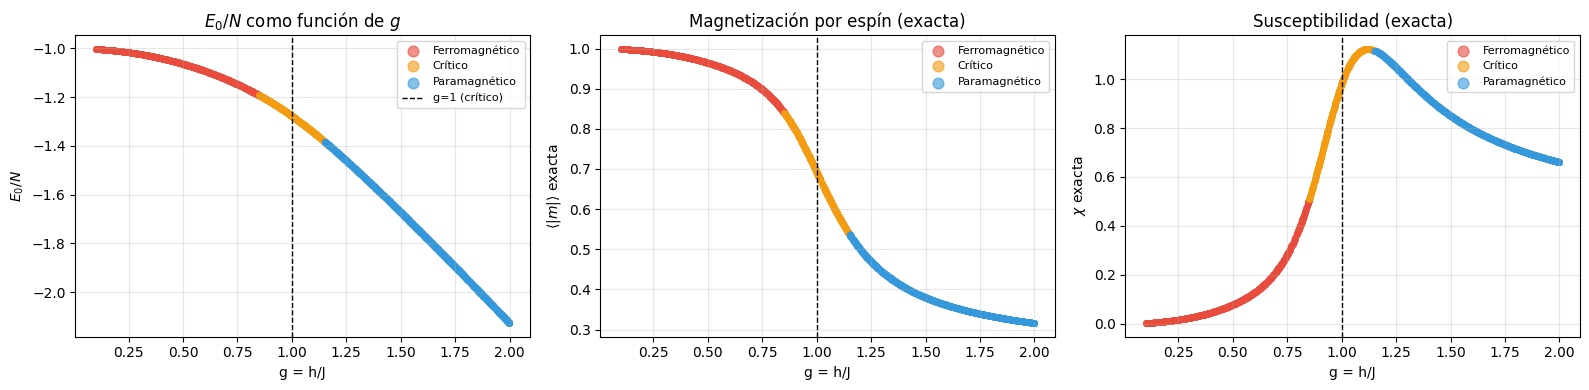

In [19]:
print("Generando dataset...")
states, targets, phases, g_vals, m_exact_all, chi_exact_all = generate_TFIM_dataset(
    N, BATCH_SIZE, G_RANGE, CRIT_EPS, NOISE_ETA
)
print(f"Dataset: {BATCH_SIZE} muestras, dim estado = {2**N}")
for k, name in PHASE_NAMES.items():
    n_k = (phases == k).sum()
    print(f"  {name}: {n_k} ({100*n_k/BATCH_SIZE:.1f}%)")

# Visualización del dataset (convenio g = h/J)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
for k, name in PHASE_NAMES.items():
    mask = phases == k
    ax.scatter(g_vals[mask], targets[mask, 1], c=PHASE_COLORS[k], s=15, alpha=0.6, label=name)
ax.axvline(1.0, color='k', linestyle='--', lw=1, label="g=1 (crítico)")
ax.set_xlabel("g = h/J"); ax.set_ylabel("$E_0/N$")
ax.set_title("$E_0/N$ como función de $g$")
ax.legend(markerscale=2, fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
for k, name in PHASE_NAMES.items():
    mask = phases == k
    ax.scatter(g_vals[mask], m_exact_all[mask], c=PHASE_COLORS[k], s=15, alpha=0.6, label=name)
ax.axvline(1.0, color='k', linestyle='--', lw=1)
ax.set_xlabel("g = h/J"); ax.set_ylabel(r"$\langle |m| \rangle$ exacta")
ax.set_title("Magnetización por espín (exacta)")
ax.legend(markerscale=2, fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
for k, name in PHASE_NAMES.items():
    mask = phases == k
    ax.scatter(g_vals[mask], chi_exact_all[mask], c=PHASE_COLORS[k], s=15, alpha=0.6, label=name)
ax.axvline(1.0, color='k', linestyle='--', lw=1)
ax.set_xlabel("g = h/J"); ax.set_ylabel(r"$\chi$ exacta")
ax.set_title("Susceptibilidad (exacta)")
ax.legend(markerscale=2, fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Ejemplo de estado con g FM=0.109:
[ 0.6878684   0.0306469   0.02417254 ...  0.00243341  0.00585871
 -0.22266775]
Ejemplo de estado con g FM=0.103:
[ 2.0052327e-01 -5.9733633e-04 -7.2150473e-03 ...  2.0376049e-02
  3.4137885e-03  7.0086765e-01]
Ejemplo de estado con g FM=0.102:
[ 0.5625762   0.01554866  0.00932233 ... -0.01840599 -0.0111918
  0.43183166]
Ejemplo de estado con g FM=0.109:
[0.24570839 0.00868542 0.00895497 ... 0.01687747 0.01740293 0.6746207 ]
Ejemplo de estado con g FM=0.108:
[ 0.5023391  -0.00470941  0.01501237 ...  0.02546185  0.01005824
  0.51244587]
Ejemplo de estado con g FM=0.104:
[-0.30721262  0.00388324  0.01253343 ...  0.01642277  0.01713845
  0.64775866]
Ejemplo de estado con g FM=0.101:
[0.489363   0.02121544 0.01674062 ... 0.01302338 0.02782046 0.5223652 ]
Ejemplo de estado con g FM=0.102:
[-0.44413862 -0.01014316  0.00433179 ...  0.00407828  0.00736168
  0.57201046]
Ejemplo de estado con g FM=0.109:
[-0.05487722  0.00421039  0.00333111 ...  0.00850743  0.011

## 4. Preprocesado y split train / val / test (70 / 15 / 15)

In [20]:
# Split estratificado para mantener proporción de fases en cada partición
# Arrastramos también m_exact y chi_exact con un índice auxiliar para poder
# recuperarlos en el test set.
idx_all = np.arange(BATCH_SIZE)

X_train, X_temp, Yr_train, Yr_temp, Yc_train, Yc_temp, idx_train, idx_temp = train_test_split(
    states, targets, phases, idx_all, test_size=0.3, random_state=42, stratify=phases
)
X_val, X_test, Yr_val, Yr_test, Yc_val, Yc_test, idx_val, idx_test = train_test_split(
    X_temp, Yr_temp, Yc_temp, idx_temp, test_size=0.5, random_state=42, stratify=Yc_temp
)

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val   = scaler_X.transform(X_val)
X_test  = scaler_X.transform(X_test)

scaler_Y = StandardScaler()
Yr_train = scaler_Y.fit_transform(Yr_train)
Yr_val   = scaler_Y.transform(Yr_val)
Yr_test  = scaler_Y.transform(Yr_test)

# Observables exactos del split de test (en el orden de X_test)
m_exact_test   = m_exact_all[idx_test]
chi_exact_test = chi_exact_all[idx_test]

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Input: {X_train.shape[1]} componentes de |ψ₀⟩")
print(f"Output regresión: [g = h/J, E₀/N] | Output clasificación: 3 clases")


Train: 2100 | Val: 450 | Test: 450
Input: 4096 componentes de |ψ₀⟩
Output regresión: [g = h/J, E₀/N] | Output clasificación: 3 clases


## 5. Modelo — Red con cabeza dual (regresión + clasificación)

```
|ψ₀⟩  (2^N)
   └─► [Linear → LayerNorm → GELU] × n_layers   (tronco compartido)
            ├─► Linear(2)                    →  (g, E₀/N)   [regresión]
            └─► Linear(hidden/2) → GELU → Linear(3)  →  fase  [clasificación]
```

In [21]:
class PhaseNet(nn.Module):
    """
    Red con cabeza dual:
      - Regresión:     |ψ₀⟩ → (g, E₀/N)
      - Clasificación: |ψ₀⟩ → P(FM), P(Crítico), P(PM)
    """
    def __init__(self, input_dim, hidden_dim, n_layers, n_phases=3):
        super().__init__()
        trunk = []
        in_f  = input_dim
        for _ in range(n_layers):
            trunk += [nn.Linear(in_f, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU()]
            in_f = hidden_dim
        self.trunk    = nn.Sequential(*trunk)
        self.head_reg = nn.Linear(hidden_dim, 2)
        self.head_cls = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, n_phases)
        )

    def forward(self, x):
        z = self.trunk(x)
        return self.head_reg(z), self.head_cls(z)


model = PhaseNet(input_dim=2**N, hidden_dim=HIDDEN_DIM, n_layers=N_LAYERS).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nParámetros entrenables: {n_params:,}")

PhaseNet(
  (trunk): Sequential(
    (0): Linear(in_features=4096, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (8): GELU(approximate='none')
    (9): Linear(in_features=256, out_features=256, bias=True)
    (10): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (11): GELU(approximate='none')
    (12): Linear(in_features=256, out_features=256, bias=True)
    (13): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (14): GELU(approximate='none')
  )
  (head_reg): Linear(in_features=256, out_features=2, bias=True)
  (head_cls): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): 

## 6. Entrenamiento

$$\mathcal{L} = \lambda_\text{reg} \cdot \text{MSE}(g,\, E_0/N) + \lambda_\text{cls} \cdot \text{CrossEntropy}(\text{fase})$$

In [22]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
loss_mse  = nn.MSELoss()
loss_ce   = nn.CrossEntropyLoss()

def to_torch(arr, dtype=torch.float32):
    return torch.tensor(arr, dtype=dtype).to(device)

X_tr  = to_torch(X_train);  Yr_tr = to_torch(Yr_train)
Yc_tr = to_torch(Yc_train, dtype=torch.long)
X_vl  = to_torch(X_val);    Yr_vl = to_torch(Yr_val)
Yc_vl = to_torch(Yc_val, dtype=torch.long)

train_losses, val_losses = [], []
best_val_loss, best_state, epochs_no_improve = float("inf"), None, 0

for epoch in range(N_EPOCHS):
    model.train()
    optimizer.zero_grad()
    out_reg, out_cls = model(X_tr)
    loss = LAMBDA_REG * loss_mse(out_reg, Yr_tr) + LAMBDA_CLS * loss_ce(out_cls, Yc_tr)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        vr, vc   = model(X_vl)
        val_loss = LAMBDA_REG * loss_mse(vr, Yr_vl) + LAMBDA_CLS * loss_ce(vc, Yc_vl)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    scheduler.step(val_loss)

    if epoch % 50 == 0 or epoch == N_EPOCHS - 1:
        print(f"Epoch {epoch:4d} | Train: {loss.item():.5f} | Val: {val_loss.item():.5f}")

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping en epoch {epoch}. Mejor val loss: {best_val_loss:.5f}")
            break

model.load_state_dict(best_state)

Epoch    0 | Train: 1.66785 | Val: 1.42128
Epoch   50 | Train: 0.00364 | Val: 0.04268

Early stopping en epoch 89. Mejor val loss: 0.03865


<All keys matched successfully>

## 7. Evaluación

In [23]:
model.eval()
with torch.no_grad():
    pred_reg_sc, pred_cls_logits = model(to_torch(X_test))

pred_reg = scaler_Y.inverse_transform(pred_reg_sc.cpu().numpy())
true_reg = scaler_Y.inverse_transform(Yr_test)
pred_cls = pred_cls_logits.argmax(dim=1).cpu().numpy()
true_cls = Yc_test

g_pred, E_pred = pred_reg[:, 0], pred_reg[:, 1]
g_real, E_real = true_reg[:, 0], true_reg[:, 1]

print("=== Regresión ===")
for i, name in enumerate(["g = h/J", "E₀/N"]):
    err = np.abs(pred_reg[:, i] - true_reg[:, i])
    print(f"  Error medio en {name}: {err.mean():.4f} ± {err.std():.4f}")

accuracy = (pred_cls == true_cls).mean()
print(f"\n=== Clasificación ===")
print(f"  Accuracy global: {accuracy:.4f} ({100*accuracy:.1f}%)")
for k, name in PHASE_NAMES.items():
    mask = true_cls == k
    if mask.sum() > 0:
        acc_k = (pred_cls[mask] == true_cls[mask]).mean()
        print(f"  {name}: {acc_k:.4f} ({mask.sum()} muestras)")

# --- Observables reconstruidos a partir del g predicho ---
# Idea: para cada muestra del test, la red predice un g_pred. Si ese g fuese
# correcto, ¿qué <|m|> y chi tendría el TFIM? Lo calculamos diagonalizando
# exactamente con (J=1, h=g_pred) y comparamos con los observables exactos
# del estado real (que ya tenemos: m_exact_test, chi_exact_test).
#
# Así medimos la propagación del error en g a la magnetización y la
# susceptibilidad. Es la forma más natural de juzgar la utilidad del modelo
# para reproducir observables, especialmente cerca de g = 1.

print("\n=== Observables reconstruidos a partir de g_pred ===")
m_pred   = np.zeros(len(g_pred))
chi_pred = np.zeros(len(g_pred))
for i, gp in enumerate(g_pred):
    gp_clip = float(np.clip(gp, 1e-3, 10.0))  # evitar valores no físicos
    H_p = build_TFIM_hamiltonian(N, 1.0, gp_clip)
    _, psi_p = diagonalize_ground_state(H_p)
    m_p, _, chi_p = compute_observables_from_psi(psi_p.real, N)
    m_pred[i]   = m_p
    chi_pred[i] = chi_p

err_m   = np.abs(m_pred   - m_exact_test)
err_chi = np.abs(chi_pred - chi_exact_test)
print(f"  Error medio en <|m|>: {err_m.mean():.4f} ± {err_m.std():.4f}")
print(f"  Error medio en chi : {err_chi.mean():.4f} ± {err_chi.std():.4f}")

# Errores específicos en la región crítica
mask_crit = np.abs(g_real - 1.0) <= CRIT_EPS
if mask_crit.sum() > 0:
    print(f"\n  En región crítica (|g-1|<{CRIT_EPS}, {mask_crit.sum()} muestras):")
    print(f"    Error medio en <|m|>: {err_m[mask_crit].mean():.4f}")
    print(f"    Error medio en chi : {err_chi[mask_crit].mean():.4f}")


=== Regresión ===
  Error medio en g = h/J: 0.0524 ± 0.0406
  Error medio en E₀/N: 0.0285 ± 0.0312

=== Clasificación ===
  Accuracy global: 0.9844 (98.4%)
  Ferromagnético: 0.9944 (177 muestras)
  Crítico: 0.9315 (73 muestras)
  Paramagnético: 0.9950 (200 muestras)

=== Observables reconstruidos a partir de g_pred ===
  Error medio en <|m|>: 0.0150 ± 0.0175
  Error medio en chi : 0.0410 ± 0.0607

  En región crítica (|g-1|<0.15, 73 muestras):
    Error medio en <|m|>: 0.0306
    Error medio en chi : 0.0769


In [ ]:
legend_fontsize = 14

## 8. Visualización

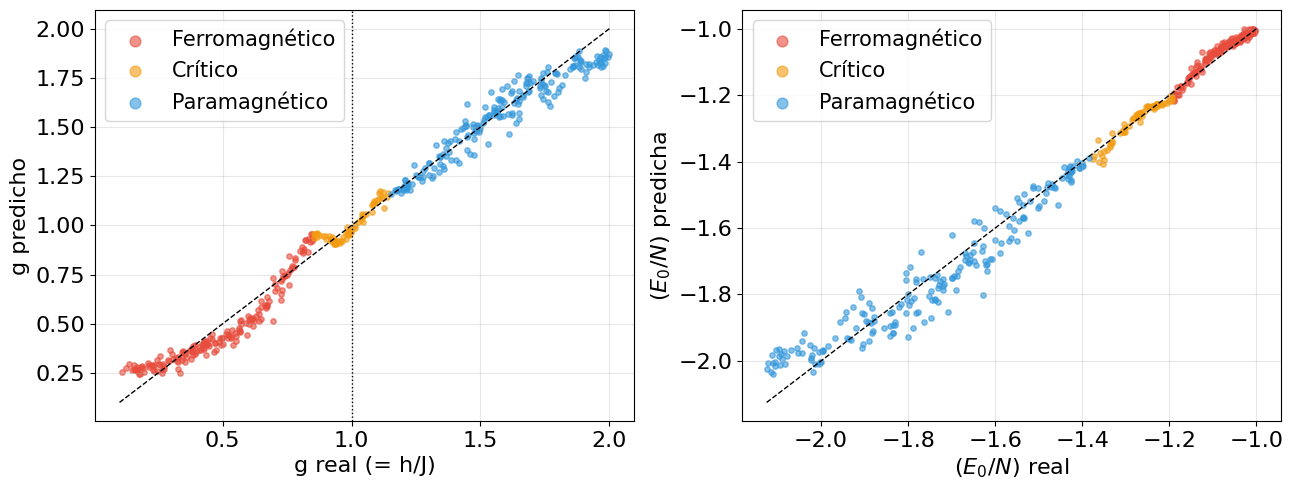

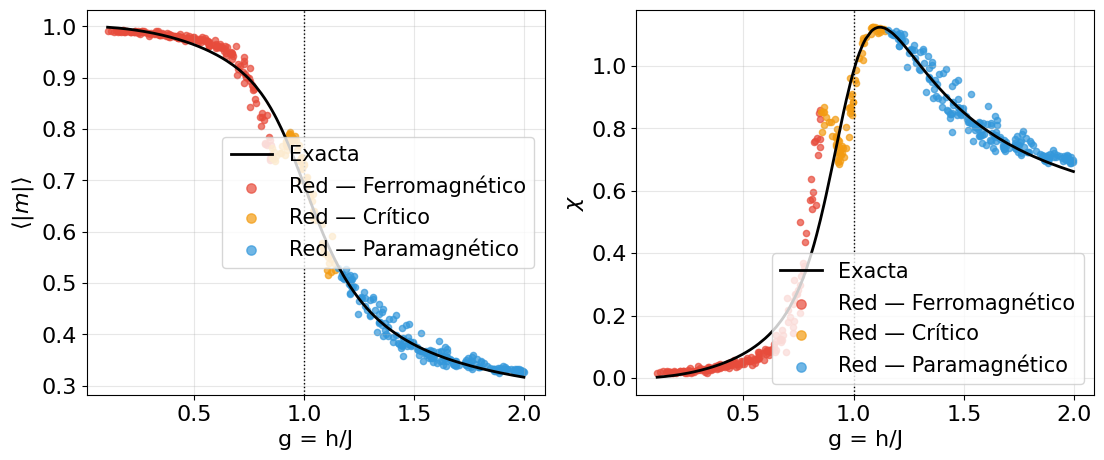

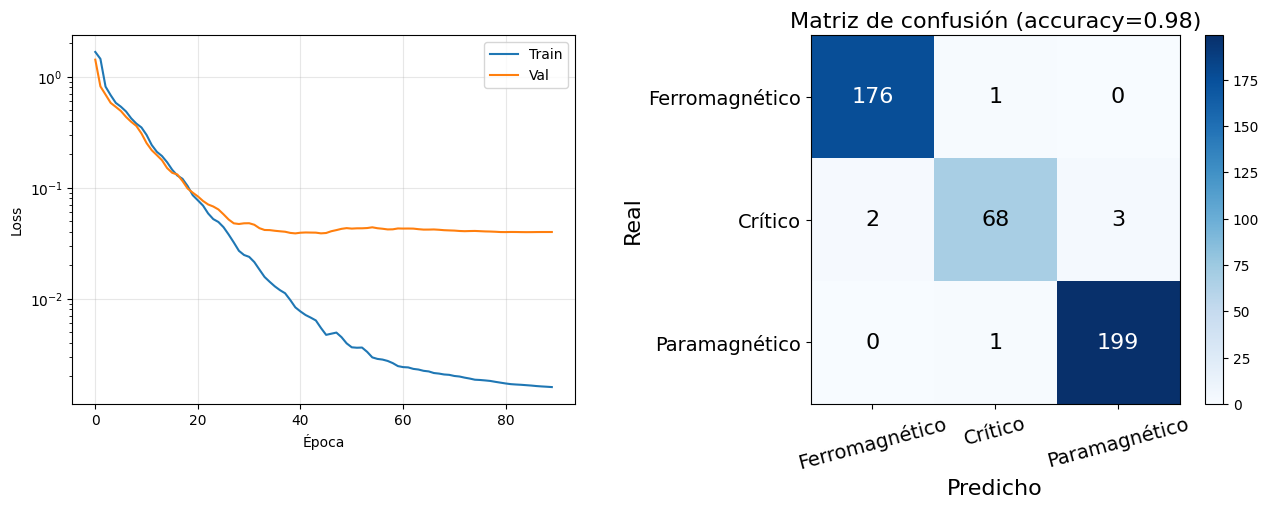


Observables guardados en: Datos\obvles_5_capas_hamiltonianlearning.txt


In [ ]:
fig1, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for k in PHASE_NAMES:
    mask = true_cls == k
    ax.scatter(g_real[mask], g_pred[mask], c=PHASE_COLORS[k], s=15, alpha=0.6, label=PHASE_NAMES[k])
lims = [G_RANGE[0], G_RANGE[1]]
ax.plot(lims, lims, 'k--', lw=1)
ax.axvline(1.0, color='k', linestyle=':', lw=1)
ax.set_xlabel("g real (= h/J)", fontsize=16); ax.set_ylabel("g predicho", fontsize=16)
ax.legend(fontsize=15, markerscale=2); ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', labelsize=16)

ax = axes[1]
for k in PHASE_NAMES:
    mask = true_cls == k
    ax.scatter(E_real[mask], E_pred[mask], c=PHASE_COLORS[k], s=15, alpha=0.6, label=PHASE_NAMES[k])
lims_e = [min(E_real.min(), E_pred.min()), max(E_real.max(), E_pred.max())]
ax.plot(lims_e, lims_e, 'k--', lw=1)
ax.set_xlabel("$(E_0/N)$ real", fontsize=16); ax.set_ylabel("$(E_0/N)$ predicha", fontsize=16)
ax.legend(fontsize=15, markerscale=2); ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.show()

fig2, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
order = np.argsort(g_real)
ax.plot(g_real[order], m_exact_test[order], 'k-', lw=2, label="Exacta")
for k in PHASE_NAMES:
    mask = true_cls == k
    ax.scatter(g_real[mask], m_pred[mask], c=PHASE_COLORS[k], s=20, alpha=0.7,
               label=f"{PHASE_NAMES[k]}")
ax.axvline(1.0, color='k', linestyle=':', lw=1)
ax.set_xlabel("g = h/J", fontsize=16); ax.set_ylabel(r"$\langle |m| \rangle$", fontsize=16)
ax.legend(fontsize=15, markerscale=1.5); ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', labelsize=16)

ax = axes[1]
ax.plot(g_real[order], chi_exact_test[order], 'k-', lw=2, label="Exacta")
for k in PHASE_NAMES:
    mask = true_cls == k
    ax.scatter(g_real[mask], chi_pred[mask], c=PHASE_COLORS[k], s=20, alpha=0.7,
               label=f"{PHASE_NAMES[k]}")
ax.axvline(1.0, color='k', linestyle=':', lw=1)
ax.set_xlabel("g = h/J", fontsize=16); ax.set_ylabel(r"$\chi$", fontsize=16)
ax.legend(fontsize=15, markerscale=1.5); ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', labelsize=16)

fig3, axes = plt.subplots(1,2, figsize=(13, 5))
ax = axes[1]
conf_mat = np.zeros((3, 3), dtype=int)
for t, p in zip(true_cls, pred_cls):
    conf_mat[t, p] += 1
im = ax.imshow(conf_mat, cmap="Blues")
labels = [PHASE_NAMES[k] for k in range(3)]
ax.set_xticks(range(3)); ax.set_xticklabels(labels, rotation=15, fontsize=14)
ax.set_yticks(range(3)); ax.set_yticklabels(labels, fontsize=14)
ax.set_xlabel("Predicho", fontsize=16); ax.set_ylabel("Real", fontsize=16)
ax.set_title(f"Matriz de confusión (accuracy={accuracy:.2f})", fontsize=16)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(conf_mat[i, j]), ha="center", va="center", fontsize=16,
                color="white" if conf_mat[i, j] > conf_mat.max() / 2 else "black")
plt.colorbar(im, ax=ax)

ax = axes[0]
ax.semilogy(train_losses, label="Train")
ax.semilogy(val_losses,   label="Val")
ax.set_xlabel("Época"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# Guardado de observables del test, ordenados por g
order = np.argsort(g_real)
out_path = os.path.join(DATA_DIR, "obvles_5_capas_hamiltonianlearning.txt")
with open(out_path, "w") as f:
    f.write("# Observables del TFIM inferidos con red de 5 capas (regresión sobre g + reconstrucción)\n")
    f.write(f"# N = {N}, J = 1.0, beta = 1.0, ruido eta = {NOISE_ETA}\n")
    f.write(f"# Convenio: g = h/J\n")
    f.write("# Columnas: g_real  g_pred  E_real(E0/N)  E_pred(E0/N)  "
            "m_exact  m_pred  chi_exact  chi_pred  fase_real  fase_pred\n")
    for idx in order:
        f.write(
            f"{g_real[idx]:8.5f}  {g_pred[idx]:8.5f}  "
            f"{E_real[idx]:10.6f}  {E_pred[idx]:10.6f}  "
            f"{m_exact_test[idx]:10.6f}  {m_pred[idx]:10.6f}  "
            f"{chi_exact_test[idx]:10.6f}  {chi_pred[idx]:10.6f}  "
            f"{int(true_cls[idx])}  {int(pred_cls[idx])}\n"
        )
print(f"\nObservables guardados en: {out_path}")


## 9. Inferencia sobre un estado del test set

Dado un vector de estado $|\psi_0\rangle$, la red predice $g$, $E_0/N$ y la fase con las probabilidades de cada clase.

In [25]:
def predict_from_state(psi, model, scaler_X, scaler_Y, device):
    """
    Dado un vector de estado |ψ₀⟩ (array 1D de longitud 2^N),
    devuelve g = h/J, E₀/N y la fase predichos con sus probabilidades.
    """
    psi_n  = psi / (np.linalg.norm(psi) + 1e-12)
    psi_sc = scaler_X.transform(psi_n.reshape(1, -1)).astype(np.float32)
    x      = torch.tensor(psi_sc).to(device)

    model.eval()
    with torch.no_grad():
        out_reg, out_cls = model(x)

    reg   = scaler_Y.inverse_transform(out_reg.cpu().numpy())[0]
    phase = out_cls.argmax(dim=1).item()
    probs = torch.softmax(out_cls, dim=1).cpu().numpy()[0]

    print(f"g = h/J predicho:  {reg[0]:.4f}")
    print(f"E₀/N predicha:     {reg[1]:.4f}")
    print(f"Fase predicha:     {PHASE_NAMES[phase]}")
    print(f"Probabilidades:")
    for k, name in PHASE_NAMES.items():
        bar = '█' * int(probs[k] * 30)
        print(f"  {name:>15}: {probs[k]:.3f}  {bar}")
    return reg, phase, probs


# Elegimos un estado aleatorio del test set
rng_infer = np.random.default_rng(7)
i = rng_infer.integers(0, len(X_test))

psi_example = scaler_X.inverse_transform(X_test[i:i+1])[0]
g_true_i, E_true_i = true_reg[i]

print(f"--- Muestra #{i} del test set ---")
print(f"Valores reales: g={g_true_i:.4f} | E₀/N={E_true_i:.4f} | Fase={PHASE_NAMES[true_cls[i]]}")
print()
reg_pred_i, phase_pred_i, probs_pred_i = predict_from_state(
    psi_example, model, scaler_X, scaler_Y, device
)
print()
print(f"Error en g:    {abs(reg_pred_i[0] - g_true_i):.4f}")
print(f"Error en E₀/N: {abs(reg_pred_i[1] - E_true_i):.4f}")
print(f"Clasificación: {'✓ correcta' if phase_pred_i == true_cls[i] else '✗ incorrecta'}")


--- Muestra #425 del test set ---
Valores reales: g=0.9835 | E₀/N=-1.2665 | Fase=Crítico

g = h/J predicho:  0.9913
E₀/N predicha:     -1.2807
Fase predicha:     Crítico
Probabilidades:
   Ferromagnético: 0.001  
          Crítico: 0.998  █████████████████████████████
    Paramagnético: 0.001  

Error en g:    0.0078
Error en E₀/N: 0.0142
Clasificación: ✓ correcta


## 10. Guardar el modelo

In [26]:
torch.save({
    "model_state_dict": model.state_dict(),
    "scaler_X_mean":  scaler_X.mean_,  "scaler_X_scale": scaler_X.scale_,
    "scaler_Y_mean":  scaler_Y.mean_,  "scaler_Y_scale": scaler_Y.scale_,
    "N": N, "hidden_dim": HIDDEN_DIM, "n_layers": N_LAYERS,
    "crit_eps": CRIT_EPS, "noise_eta": NOISE_ETA, "phase_names": PHASE_NAMES,
}, "phase_net_model.pt")
print("Modelo guardado en phase_net_model.pt")

Modelo guardado en phase_net_model.pt


In [27]:
print(N)

12
